# ML Models Comparison on Iris Dataset
This notebook compares SVM, Logistic Regression, and KNN using Accuracy and Recall, along with visualization.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, recall_score

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

## 2. Load Dataset

In [2]:
df = pd.read_csv("Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## 3. Prepare Data

In [3]:
X = df.drop(columns=["Species", "Id"])
y = df["Species"]

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 4. Train Models

In [4]:
models = {
    "SVM": SVC(kernel='linear'),
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, average='macro')
    
    results[name] = {"Accuracy": acc, "Recall": rec}

results

{'SVM': {'Accuracy': 0.9666666666666667, 'Recall': 0.9629629629629629},
 'Logistic Regression': {'Accuracy': 1.0, 'Recall': 1.0},
 'KNN': {'Accuracy': 1.0, 'Recall': 1.0}}

## 5. Convert Results to DataFrame

In [5]:
results_df = pd.DataFrame(results).T
results_df

,Accuracy,Recall
SVM,0.966667,0.962963
Logistic Regression,1.000000,1.000000
KNN,1.000000,1.000000


## 6. Plot Accuracy

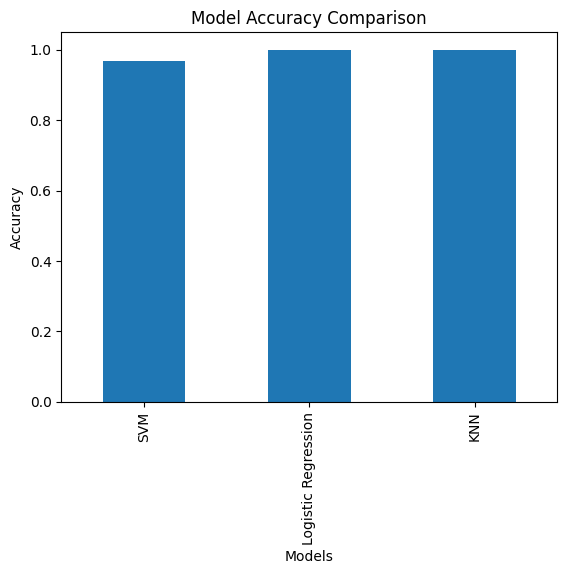

In [6]:
plt.figure()
results_df["Accuracy"].plot(kind='bar')
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

## 7. Plot Recall

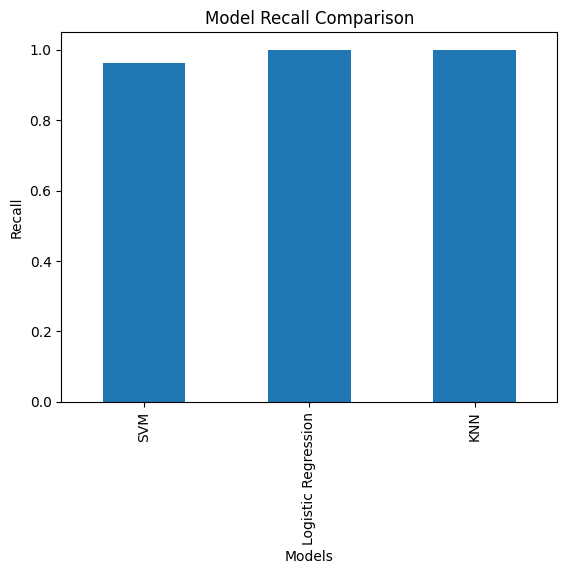

In [7]:
plt.figure()
results_df["Recall"].plot(kind='bar')
plt.title("Model Recall Comparison")
plt.xlabel("Models")
plt.ylabel("Recall")
plt.show()

## Conclusion
This notebook compares three ML models:
- SVM
- Logistic Regression
- KNN

Metrics used: Accuracy and Recall.